In [7]:
!pip install optuna catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold
import optuna
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


In [8]:
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')
submission = pd.read_csv('sample_submission.csv')

In [9]:
df = pd.concat([train,test])
df = df.reset_index()
df.head()

,index,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [10]:
df.isnull().sum().sort_values(ascending=False).head(36)

,0
PoolQC,2909
MiscFeature,2814
Alley,2721
Fence,2348
MasVnrType,1766
SalePrice,1459
FireplaceQu,1420
LotFrontage,486
GarageYrBlt,159
GarageCond,159


In [11]:
df.fillna({'PoolQC':'None'},inplace=True)


In [12]:
df.fillna({'MiscFeature':'None'},inplace=True)
df.fillna({'Alley':'None'},inplace=True)
df.fillna({'Fence':'None'},inplace=True)
df.fillna({'MasVnrType':'None'},inplace=True)
df.fillna({'FireplaceQu':'None'},inplace=True)
df.fillna({'LotFrontage':0},inplace=True)
df.fillna({'GarageYrBlt':0},inplace=True)
df.fillna({'GarageFinish':'None'},inplace=True)
df.fillna({'GarageQual':'None'},inplace=True)
df.fillna({'GarageCond':'None'},inplace=True)
df.fillna({'GarageType':'None'},inplace=True)
df.fillna({'BsmtExposure':'None'},inplace=True)
df.fillna({'BsmtCond':'None'},inplace=True)
df.fillna({'BsmtQual':'None'},inplace=True)
df.fillna({'BsmtFinType2':'None'},inplace=True)
df.fillna({'BsmtFinType1':'None'},inplace=True)
df.fillna({'MasVnrArea':0},inplace=True)
df.fillna({'MSZoning':'RL'},inplace=True)
df.fillna({'Functional':'Typ'},inplace=True)
df.fillna({'BsmtFullBath':0},inplace=True)
df.fillna({'BsmtHalfBath':0},inplace=True)
df.fillna({'TotalBsmtSF':0},inplace=True)
df.fillna({'BsmtUnfSF':0},inplace=True)
df.fillna({'Utilities':'AllPub'},inplace=True)
df.fillna({'Electrical':'SBrkr'},inplace=True)
df.fillna({'KitchenQual':'None'},inplace=True)
df.fillna({'BsmtFinSF2':0},inplace=True)
df.fillna({'BsmtFinSF1':0},inplace=True)
df.fillna({'GarageCars':0},inplace=True)
df.fillna({'SaleType':'WD'},inplace=True)
df.fillna({'Exterior2nd':'Exterior2nd'},inplace=True)
df.fillna({'GarageArea':0},inplace=True)
df.fillna({'Exterior1st':'Exterior1st'},inplace=True)




In [13]:
df.isnull().sum().sort_values(ascending=False).head()


,0
SalePrice,1459
index,0
MSSubClass,0
MSZoning,0
LotFrontage,0


In [14]:
df['BsmtFullBath'] = df['BsmtFullBath'].astype(int)
df['BsmtHalfBath'] = df['BsmtHalfBath'].astype(int)
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)
df['GarageCars'] = df['GarageCars'].astype(int)

Feature engineering devam edilecek


In [15]:
numeric_df = df.select_dtypes(include = 'number')

In [16]:
numeric_df.head()

,index,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,0,1,60,65.0,8450,7,5,2003,2003,196.0,...,0,61,0,0,0,0,0,2,2008,208500.0
1,1,2,20,80.0,9600,6,8,1976,1976,0.0,...,298,0,0,0,0,0,0,5,2007,181500.0
2,2,3,60,68.0,11250,7,5,2001,2002,162.0,...,0,42,0,0,0,0,0,9,2008,223500.0
3,3,4,70,60.0,9550,7,5,1915,1970,0.0,...,0,35,272,0,0,0,0,2,2006,140000.0
4,4,5,60,84.0,14260,8,5,2000,2000,350.0,...,192,84,0,0,0,0,0,12,2008,250000.0


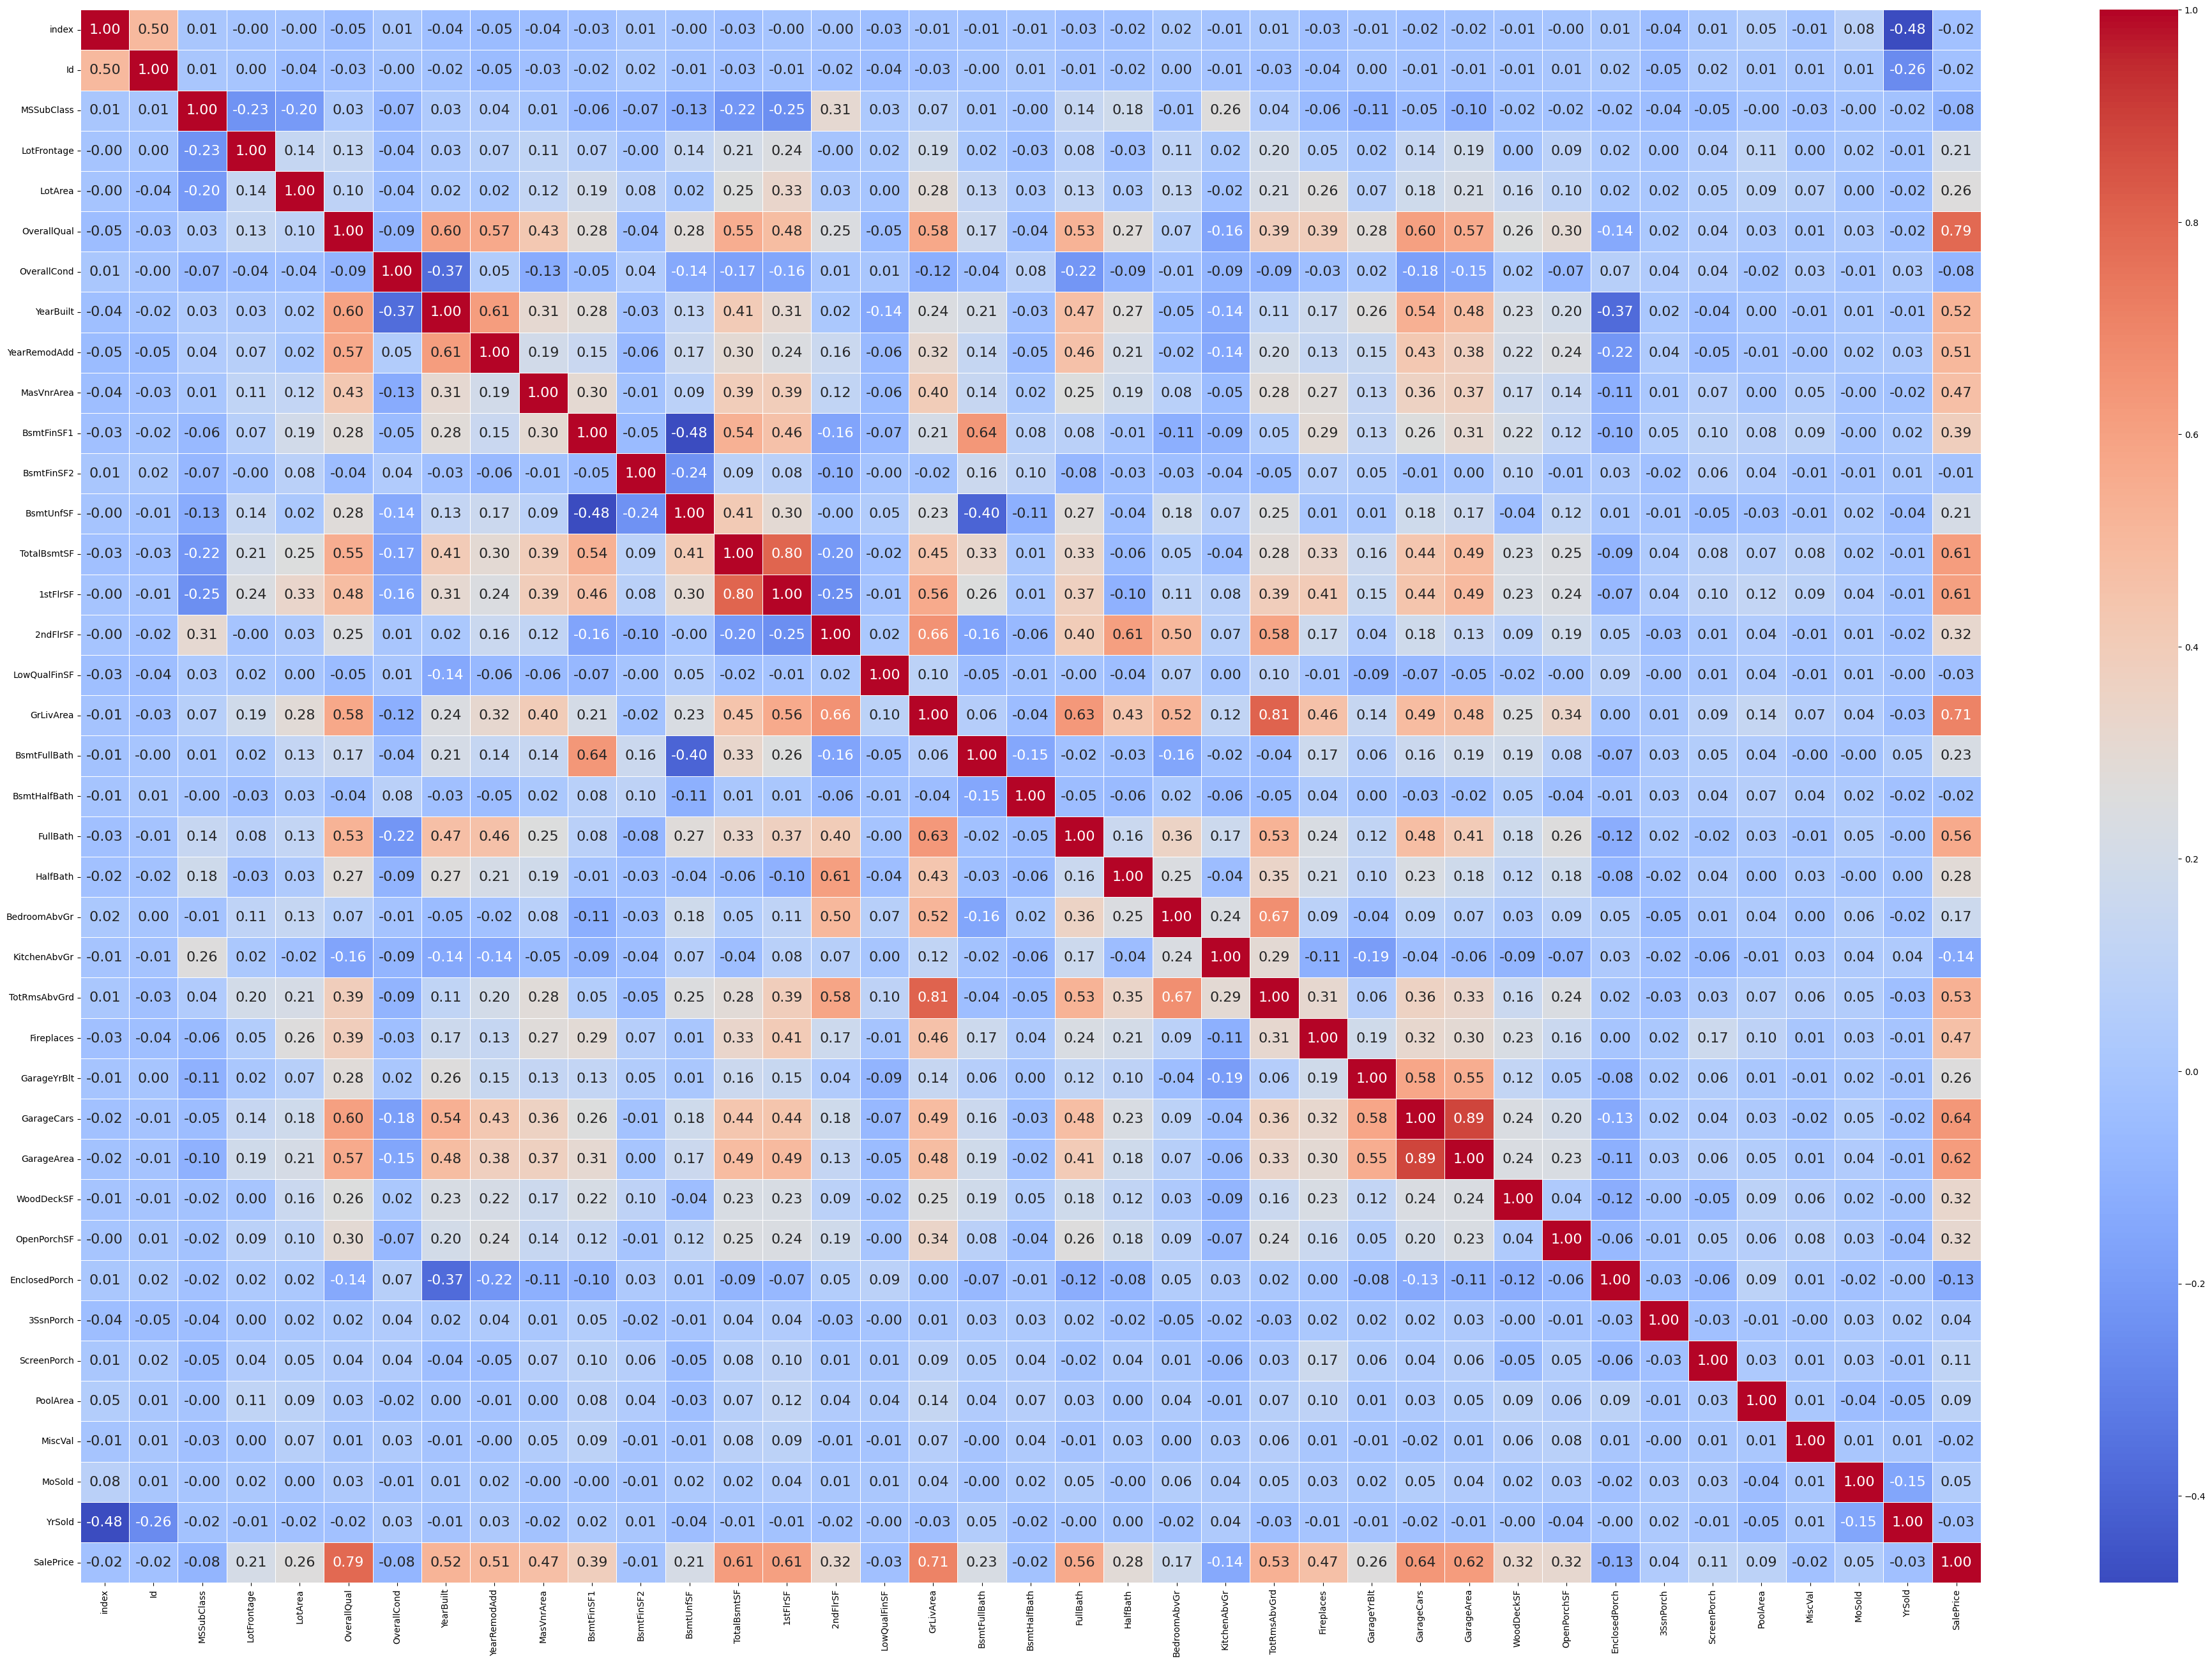

In [17]:
df_corr = numeric_df.corr()
plt.figure(figsize = (48,32))
sns.heatmap(df_corr, annot = True, cmap = "coolwarm", fmt = "0.2f",linewidths = 0.5,annot_kws = {"size":16})
plt.show()

In [18]:
df['GarageYrBlt'] = (df['YrSold'] - df['GarageYrBlt']).clip(lower=0)
df['YearBuilt'] = (df['YrSold'] - df['YearBuilt']).clip(lower=0)
df['YearRemodAdd'] = (df['YrSold'] - df['YearRemodAdd']).clip(lower=0)

df.drop(['YrSold','MoSold'],axis = 1 ,inplace = True)


In [19]:
df['BsmtFinSF'] = df['BsmtFinSF1'] + df['BsmtFinSF2']
df['TotalFlrSF'] = df['1stFlrSF'] + df['2ndFlrSF']

df.drop(['BsmtFinSF1','BsmtFinSF2','1stFlrSF','2ndFlrSF','TotalBsmtSF'],axis = 1 , inplace = True)


In [20]:
df['TotalBaths'] = df['FullBath'] + (0.5*df['HalfBath'])+ df['BsmtFullBath'] + (0.5*df['BsmtHalfBath'])

df.drop(['FullBath','HalfBath','BsmtFullBath','BsmtHalfBath'],axis = 1 , inplace = True)


In [21]:
df['GarageAreaPerCar'] = df['GarageArea']/df['GarageCars']
df.fillna({'GarageAreaPerCar': 0},inplace=True)
df.drop(['GarageArea','GarageCars'],axis = 1 , inplace = True)

In [22]:
numerical_cols = [cname for cname in df.columns if df[cname].dtype != 'object' and cname != 'SalePrice']
numerical_cols.pop(0)

skew_df = pd.DataFrame(numerical_cols,columns=['Feature'])
skew_df['Skew'] = skew_df['Feature'].apply(lambda feature: scipy.stats.skew(df[feature]))
skew_df['Absolute Skew'] = skew_df['Skew'].apply(abs)
skew_df['Skewed'] = skew_df['Absolute Skew'].apply(lambda x : True if x>=0.5 else False)




In [23]:

skew_df

,Feature,Skew,Absolute Skew,Skewed
0,Id,0.000000,0.000000,False
1,MSSubClass,1.375457,1.375457,True
2,LotFrontage,0.022013,0.022013,False
3,LotArea,12.822431,12.822431,True
4,OverallQual,0.197110,0.197110,False
5,OverallCond,0.570312,0.570312,True
6,YearBuilt,0.598651,0.598651,True
7,YearRemodAdd,0.450398,0.450398,False
8,MasVnrArea,2.613592,2.613592,True
9,BsmtUnfSF,0.919339,0.919339,True


In [24]:
df[numerical_cols].describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtUnfSF,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,BsmtFinSF,TotalFlrSF,TotalBaths,GarageAreaPerCar
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,...,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,1460.000000,57.137718,57.766701,10168.114080,6.089072,5.564577,36.480301,23.529633,101.396026,560.579993,...,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,490.837273,1496.065433,2.218397,257.558056
std,842.787043,42.517628,33.481636,7886.996359,1.409947,1.113131,30.335764,20.890468,178.854579,439.590889,...,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,477.209821,503.675790,0.808840,86.049842
min,1.000000,20.000000,0.000000,1300.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,1.000000,0.000000
25%,730.500000,20.000000,43.000000,7478.000000,5.000000,5.000000,7.000000,4.000000,0.000000,220.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1120.000000,1.500000,226.500000
50%,1460.000000,50.000000,63.000000,9453.000000,6.000000,5.000000,35.000000,15.000000,0.000000,467.000000,...,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,457.000000,1440.000000,2.000000,262.666667
75%,2189.500000,70.000000,78.000000,11570.000000,7.000000,6.000000,54.500000,43.000000,163.500000,805.000000,...,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,805.500000,1742.500000,2.500000,294.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,136.000000,60.000000,1600.000000,2336.000000,...,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,5644.000000,5642.000000,7.000000,924.000000


In [25]:
for column in skew_df.query("Skewed == True")['Feature'].values:
  df[column] = np.log1p(df[column])

In [26]:
skew_df.query("Skewed == True")['Feature'].values

array(['MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'MasVnrArea',
       'BsmtUnfSF', 'LowQualFinSF', 'GrLivArea', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
       'PoolArea', 'MiscVal', 'BsmtFinSF', 'TotalFlrSF'], dtype=object)

In [27]:
num_cols = df.select_dtypes(include = ['int64','float64']).columns
num_cols = num_cols.drop(['SalePrice','Id'])

In [28]:
categorical_cols = df.select_dtypes(include = 'object').columns
df_categorical = df[categorical_cols].copy()
df_categorical.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
1,RL,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
2,RL,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
3,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,None,None,None,WD,Abnorml
4,RL,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal


In [29]:
ordinal_1 = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu',
                 'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_1:
    if 'None' in df[col].value_counts().index:
        df[col] = df[col].map({"None":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}).astype('int')
    else:
        df[col] = df[col].map({"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}).astype('int')

In [30]:
ordinal_2 = ['LotShape', 'LandContour', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'Utilities', 'CentralAir', 'Functional', 'GarageFinish', 'PavedDrive', 'Fence']

df['LotShape'] = df['LotShape'].map({"None":0,"IR3":1,"IR2":2,"IR1":3,"Reg":4}).astype('int')
df['LandContour'] = df['LandContour'].map({"None":0,"Low":1,"Bnk":2,"HLS":3,"Lvl":4}).astype('int')
df['LandSlope'] = df['LandSlope'].map({"None":0,"Sev":1,"Mod":2,"Gtl":3}).astype('int')
df['BsmtExposure'] = df['BsmtExposure'].map({"None":0, "No":1,"Mn":2,"Av":3,"Gd":4}).astype('int')
df['BsmtFinType1'] = df['BsmtFinType1'].map({"None":0, "Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
df['BsmtFinType2'] = df['BsmtFinType2'].map({"None":0, "Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
df['Utilities'] = df['Utilities'].map({"None":0,"ELO":1,"NoSeWa":2,"NoSewr":3,"AllPub":4}).astype('int')
df['CentralAir'] = df['CentralAir'].map({"None":0,"N":1,"Y":2}).astype('int')
df['Functional'] = df['Functional'].map({"None":0,"Sal":1,"Sev":2,"Maj2":3,"Maj1":4,"Mod":5,"Min2":6,
                                         "Min1":7,"Typ":8}).astype('int')
df['GarageFinish'] = df['GarageFinish'].map({"None":0,"Unf":1,"RFn":2,"Fin":3}).astype('int')
df['PavedDrive'] = df['PavedDrive'].map({"None":0,"N":1,"P":2,"Y":3}).astype('int')
df['Fence'] = df['Fence'].map({"None":0, "MnWw":1,"GdWo":2,"MnPrv":3,"GdPrv":4}).astype('int')

In [31]:
df_categorical = df_categorical.drop(columns=ordinal_1)
df_categorical = df_categorical.drop(columns=ordinal_2)

# Get the rest of the categorical data for one hot encoding
ohe_ = df_categorical.columns.tolist()

# Convert categorical columns to one-hot encoded columns, dropping the first column for each
df_encoded = pd.get_dummies(df[ohe_], drop_first=True).astype(int)

# Concatenate the one-hot encoded columns with the original Dataframe
df = pd.concat([df.drop(columns=ohe_), df_encoded], axis=1)

In [32]:
train = df.iloc[:train.shape[0]]
test = df.iloc[train.shape[0]:]

train.drop(['Id'], axis=1, inplace=True)
test.drop(['SalePrice', 'Id'], axis=1, inplace=True)

/tmp/ipykernel_10578/1272169676.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.drop(['Id'], axis=1, inplace=True)
/tmp/ipykernel_10578/1272169676.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(['SalePrice', 'Id'], axis=1, inplace=True)


In [33]:
log_target = np.log(train['SalePrice'])

train.drop(['SalePrice'], axis=1, inplace=True)

/tmp/ipykernel_10578/3208630441.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.drop(['SalePrice'], axis=1, inplace=True)


In [34]:
# # Define objective function for Optuna for catboost
# def objective_cat(trial):
#     # Define hyperparameters to optimize
#     catboost_params = {
#         'iterations': trial.suggest_int('iterations', 1000, 8000),
#         'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
#         'depth': trial.suggest_int('depth', 3, 7),
#         'eval_metric': 'RMSE',
#     }

#     # Initialize models with suggested parameters
#     catboost_model = CatBoostRegressor(**catboost_params, verbose=0)

#     # Train models
#     catboost_model.fit(train, log_target)

#     # Calculate RMSE
#     kf = KFold(n_splits=10)
#     catboost_rmse = np.exp(np.sqrt(-cross_val_score(catboost_model, train, log_target, scoring='neg_mean_squared_error', cv=kf)))

#     # Return average RMSE
#     return np.mean(catboost_rmse)

In [35]:
# # Define objective function for Optuna for xgboost
# def objective_xgb(trial):
#     # Define hyperparameters to optimize
#     xgboost_params = {
#         'n_estimators': trial.suggest_int('n_estimators', 1000, 8000),
#         'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
#         'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.2, 0.6),
#         'subsample': trial.suggest_uniform('subsample', 0.4, 0.8),
#         'min_child_weight': trial.suggest_int('min_child_weight', 2, 5),
#     }

#     # Initialize models with suggested parameters
#     xgb_model = XGBRegressor(**xgboost_params, verbosity=0)

#     # Train models
#     xgb_model.fit(train, log_target)

#     # Calculate RMSE
#     kf = KFold(n_splits=10)
#     xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, train, log_target, scoring='neg_mean_squared_error', cv=kf)))

#     # Return average RMSE
#     return np.mean(xgb_rmse)

In [36]:
# # Optimize hyperparameters catboost
# study_cat = optuna.create_study(direction='minimize')
# study_cat.optimize(objective_cat, n_trials=50)

In [37]:
# # Optimize hyperparameters xgboost
# study_xgb = optuna.create_study(direction='minimize')
# study_xgb.optimize(objective_xgb, n_trials=50)

In [38]:
# # Get best parameters
# best_params_cat = study_cat.best_params
# best_params_xgb = study_xgb.best_params

In [39]:
# best_params_cat
# study_cat.best_value
# best_params_xgb
# study_xgb.best_value

In [40]:
best_params_cat = {
    'iterations': 6623,
    'learning_rate': 0.01711,
    'depth': 5,
    'eval_metric':'RMSE',
}

best_params_xgb = {
    'n_estimators': 6696,
    'learning_rate': 0.00630,
    'colsample_bytree': 0.22301,
    'subsample': 0.45878,
    'min_child_weight': 3,
}

In [41]:
# Use best parameters to train final models
catboost_model = CatBoostRegressor(**best_params_cat, verbose=0)
xgb_model = XGBRegressor(**best_params_xgb, verbosity=0)

catboost_model.fit(train, log_target)
xgb_model.fit(train, log_target)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.22301, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.0063, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=6696,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
# Calculate RMSE CatBoost
kf = KFold(n_splits=10)
catboost_rmse = np.exp(np.sqrt(-cross_val_score(catboost_model, train, log_target, scoring='neg_mean_squared_error', cv=kf)))

In [44]:
xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, train, log_target, scoring='neg_mean_squared_error', cv=kf)))

In [45]:
print(np.mean(catboost_rmse))
print(np.mean(xgb_rmse))

1.1264652027067485
1.12667753836773


In [46]:
final_predictions = (
    0.80 * np.exp(catboost_model.predict(test)) +
    0.20 * np.exp(xgb_model.predict(test))
)

In [47]:
# Save test predictions to file
output = pd.DataFrame({'Id': test.index+1, 'SalePrice': final_predictions})
output.to_csv('submission.csv', index=False)